In [6]:
!pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
rating = pd.read_csv("ratings.csv")
rating.head() 

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
movies = pd.read_csv("movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [15]:
rating.shape

(100836, 4)

In [17]:
rating['userId'].nunique()

610

In [18]:
rating['movieId'].nunique()

9724

In [19]:
rating.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [20]:
rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

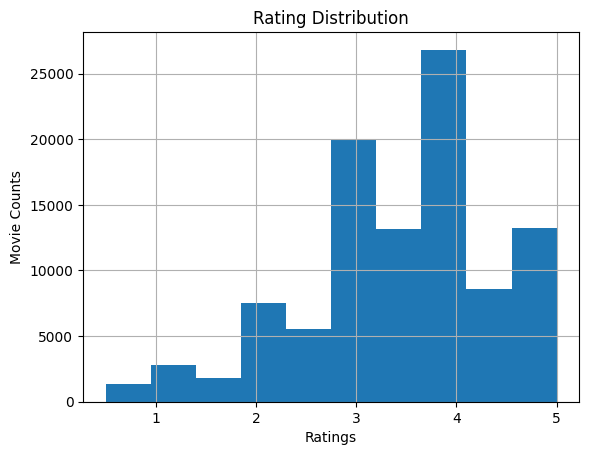

In [24]:
rating['rating'].hist(bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Movie Counts")
plt.show()

In [25]:
user_counts = rating.groupby("userId").size()
user_counts

userId
1       232
2        29
3        39
4       216
5        44
       ... 
606    1115
607     187
608     831
609      37
610    1302
Length: 610, dtype: int64

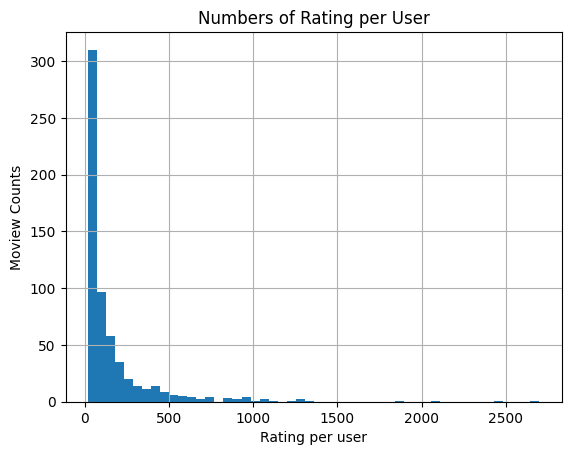

In [33]:
user_counts.hist(bins=50)
plt.title("Numbers of Rating per User")
plt.xlabel("Rating per user")
plt.ylabel("Moview Counts")
plt.show()

In [35]:
# Popular movies
moview_counts = rating.groupby('movieId').size()
moview_counts

movieId
1         215
2         110
3          52
4           7
5          49
         ... 
193581      1
193583      1
193585      1
193587      1
193609      1
Length: 9724, dtype: int64

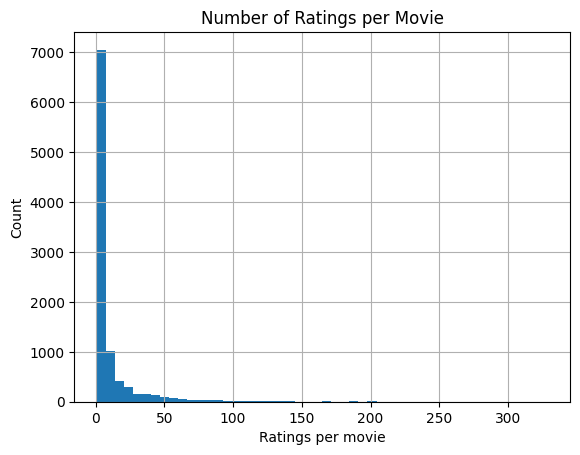

In [37]:
moview_counts.hist(bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings per movie")
plt.ylabel("Count")
plt.show()

In [38]:
# Sparsity check(critical)
num_users = rating['userId'].nunique()
num_movies = rating['movieId'].nunique()

total_possible = num_users * num_movies
actual_ratings = len(rating)

sparsity = 1 - (actual_ratings / total_possible)

print("Sparsity:", sparsity)

Sparsity: 0.9830003169443864


In [45]:
# Top Movies (Popularity Bias)
top_movies = rating.groupby('movieId')['rating'].mean().sort_values(ascending=False).head(10)

top_movies = top_movies.reset_index()
top_movies = top_movies.merge(movies, on='movieId')

print(top_movies[['title', 'rating']])

                                               title  rating
0               Heidi Fleiss: Hollywood Madam (1995)     5.0
1                               Che: Part Two (2008)     5.0
2  Vampire in Venice (Nosferatu a Venezia) (Nosfe...     5.0
3                           Idiots and Angels (2008)     5.0
4               Louis Theroux: Law & Disorder (2008)     5.0
5                                True Stories (1986)     5.0
6                Red Sorghum (Hong gao liang) (1987)     5.0
7  Man and a Woman, A (Un homme et une femme) (1966)     5.0
8                       Wings, Legs and Tails (1986)     5.0
9          My Life as McDull (Mak dau goo si) (2001)     5.0


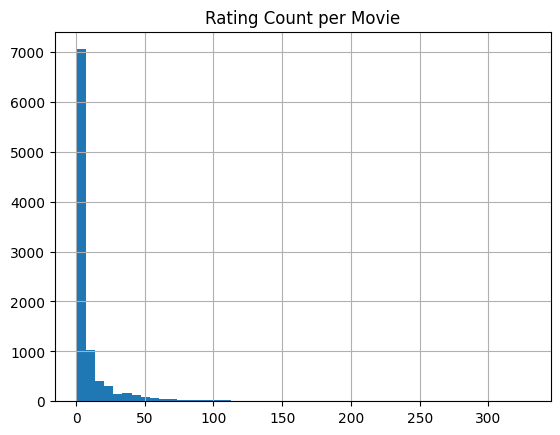

In [46]:
# Rating Variance per Movie
movie_stats = rating.groupby('movieId')['rating'].agg(['mean', 'count'])

movie_stats['count'].hist(bins=50)
plt.title("Rating Count per Movie")
plt.show()

In [47]:
# Step 1: After EDA → Add this section
# Trainf SVD model

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

# Prepare data
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(rating[['userId', 'movieId', 'rating']], reader)

# Train - Test data
trainset, testset = surprise_split(data, test_size=0.2)

# Train SVD model

model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.02    
)

model.fit(trainset)



In [48]:
# Evalute the model
predictions = model.test(testset)
rmse = accuracy.rmse(predictions)
rmse

RMSE: 0.8707


0.8706923394221534

In [49]:
# Precision@K

from collections import defaultdict

def precision_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []

    for uid, ratings in user_est_true.items():
        ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = ratings[:k]

        relevant = sum((true >= threshold) for (_, true) in top_k)
        recommended = sum((est >= threshold) for (est, _) in top_k)

        if recommended == 0:
            precisions.append(0)
        else:
            precisions.append(relevant / recommended)

    return sum(precisions) / len(precisions)


precision = precision_at_k(predictions)
print("Precision@5:", precision)

Precision@5: 0.8537431693989092


In [50]:
# =========================================
# STEP 8: SAMPLE RECOMMENDATIONS
# =========================================

def get_top_n(predictions, n=5):
    top_n = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

top_n = get_top_n(predictions, n=5)

# Show recommendations for one user
for user, recs in list(top_n.items())[:1]:
    print(f"User {user} recommendations:")
    for movie, score in recs:
        print(movie, score)

User 608 recommendations:
1221 4.4934566872501955
3996 4.351855546333686
1206 4.344890336691547
1288 4.249785059209598
5445 4.249209413094812
